# Circular Fingerprint-LIME-FragmentContrib-ExplainableAI



## Data loading and Preprocessing



In [ ]:
import multiprocessing

print("Number of CPU cores:", multiprocessing.cpu_count())

Number of CPU cores: 2


In [ ]:
# For Reporducibility
import numpy as np
np.random.seed(42)


In [ ]:
from google.colab import drive
drive.mount("....")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Primary dataset

Acquisition of the primary molecular dataset of the human acetylcholinesterase inhibitor was done from ChEMBL database(ID:ChEMBL22).

In [ ]:
# Load dataset
import pandas as pd
df=pd.read_excel(".....")
df.head(5)

,Molecule ChEMBL ID,Smiles,IC50,classLabel,IsValidSMILES,Morgan_FP,Molecule,Fingerprint,PCA1,PCA2,tSNE1,tSNE2,MolecularWeight,Frequency,cleanedMol
0,CHEMBL94,CNC(=O)Oc1ccc2c(c1)[C@]1(C)CCN(C)[C@@H]1N2C,28.0,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e880b0>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.738898,-1.494784,-52.761700,-42.736099,275.352,27,CNC(=O)Oc1ccc2c(c1)[C@]1(C)CCN(C)[C@@H]1N2C
1,CHEMBL207777,Cc1ccccc1NC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,97.0,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88190>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.014164,-1.325272,-63.027809,-53.765778,325.364,1,Cc1ccccc1NC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2
2,CHEMBL205967,CCNC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,2420.0,0,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88270>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.235565,-1.559108,-61.968063,-54.078575,263.293,1,CCNC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2
3,CHEMBL60119,Cc1ccc2c(N)c3c(nc2c1)CCCC3,100.0,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88430>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,2.705664,0.148113,57.758297,-8.911607,212.296,4,Cc1ccc2c(N)c3c(nc2c1)CCCC3
4,CHEMBL294525,CCCCCCCNc1c2c(nc3cc([N+](=O)[O-])ccc13)CCCC2,290.0,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e884a0>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,3.600017,-0.978574,61.242554,5.783804,341.455,3,CCCCCCCNc1c2c(nc3cc([N+](=O)[O-])ccc13)CCCC2


### Features Generation






Circular fingerprints encode molecular structure by considering the environment around each atom up to a specified radius. This method captures structural information that is useful for tasks such as molecular similarity searching and property prediction. The circular fingerprint featurizer from deepchem featurizer library was adopted, documentation can be found here(DeepChem, 2024):[(Source)](https://deepchem.readthedocs.io/en/latest/api_reference/featurizers.html)

In [ ]:
df.to_csv(".....", index=False)

In [ ]:
!pip install deepchem

In [ ]:
pip install rdkit

In [ ]:
import deepchem as dc
dataset_file = 'inhibitor.csv'
task = ['classLabel']
featurizer_func =dc.feat.CircularFingerprint(size=1024, radius=4)
loader = dc.data.CSVLoader(tasks=task, feature_field='cleanedMol', featurizer=featurizer_func)
dataset = loader.create_dataset(dataset_file)

[16:52:44] DEPRECATION WARNING: please use MorganGenerator
[16:52:44] DEPRECATION WARNING: please use MorganGenerator
[16:52:44] DEPRECATION WARNING: please use MorganGenerator
[16:52:44] DEPRECATION WARNING: please use MorganGenerator
[16:52:44] DEPRECATION WARNING: please use MorganGenerator
[16:52:44] DEPRECATION WARNING: please use MorganGenerator
[16:52:44] DEPRECATION WARNING: please use MorganGenerator
[16:52:44] DEPRECATION WARNING: please use MorganGenerator
[16:52:44] DEPRECATION WARNING: please use MorganGenerator
[16:52:44] DEPRECATION WARNING: please use MorganGenerator
[16:52:44] DEPRECATION WARNING: please use MorganGenerator
[16:52:44] DEPRECATION WARNING: please use MorganGenerator
[16:52:44] DEPRECATION WARNING: please use MorganGenerator
[16:52:44] DEPRECATION WARNING: please use MorganGenerator
[16:52:44] DEPRECATION WARNING: please use MorganGenerator
[16:52:44] DEPRECATION WARNING: please use MorganGenerator
[16:52:44] DEPRECATION WARNING: please use MorganGenerat

In [ ]:
transformer = dc.trans.BalancingTransformer(dataset=dataset)
dataset = transformer.transform(dataset)

In [ ]:
dataset

<DiskDataset X.shape: (np.int64(4077), np.int64(1024)), y.shape: (np.int64(4077), np.int64(1)), w.shape: (np.int64(4077), np.int64(1)), task_names: ['classLabel']>

In [ ]:
pd_dataset=pd.DataFrame(dataset.X)

In [ ]:
import pandas as pd
# Create a dictionary to map old column names to new column names
column_rename_map = {old_column: f"fp_{old_column}" for old_column in pd_dataset.columns}

# Rename the columns
pd_dataset.rename(columns=column_rename_map, inplace=True)

In [ ]:
pd_dataset

,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,...,fp_1014,fp_1015,fp_1016,fp_1017,fp_1018,fp_1019,fp_1020,fp_1021,fp_1022,fp_1023
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4072,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4073,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4074,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4075,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_withFeatures = pd.concat([df, pd_dataset.loc[:, 'fp_0':]], axis=1)
df_withFeatures

,Molecule ChEMBL ID,Smiles,IC50,classLabel,IsValidSMILES,Morgan_FP,Molecule,Fingerprint,PCA1,PCA2,...,fp_1014,fp_1015,fp_1016,fp_1017,fp_1018,fp_1019,fp_1020,fp_1021,fp_1022,fp_1023
0,CHEMBL94,CNC(=O)Oc1ccc2c(c1)[C@]1(C)CCN(C)[C@@H]1N2C,28.00,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e880b0>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.738898,-1.494784,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,CHEMBL207777,Cc1ccccc1NC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,97.00,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88190>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.014164,-1.325272,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,CHEMBL205967,CCNC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,2420.00,0,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88270>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.235565,-1.559108,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,CHEMBL60119,Cc1ccc2c(N)c3c(nc2c1)CCCC3,100.00,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88430>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,2.705664,0.148113,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CHEMBL294525,CCCCCCCNc1c2c(nc3cc([N+](=O)[O-])ccc13)CCCC2,290.00,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e884a0>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,3.600017,-0.978574,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4072,CHEMBL4077157,O=C(Nc1ccc(CN2CCOCC2)cc1C(=O)C(=O)N1C(=O)CCC1=...,229.08,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfdd327c30>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-0.478199,1.261641,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4073,CHEMBL3906317,COc1cccc2c1C=[N+](c1ccccc1C(F)(F)F)CC2.[Br-],10000.00,0,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfdd327ca0>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-0.671263,-0.016301,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4074,CHEMBL4800328,COc1cccc2cc[n+](-c3ccc(C)cc3)cc12.[Br-],1080.00,0,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfdd327d10>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-0.586529,-0.433179,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4075,CHEMBL4797670,COc1ccc(-[n+]2ccc3cccc(OC)c3c2)cc1.[Br-],140.00,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfdd327d80>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-0.677524,-0.748477,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Drop any feature containing null values
df_withFeatures.dropna(axis=1)

,Molecule ChEMBL ID,Smiles,IC50,classLabel,IsValidSMILES,Morgan_FP,Molecule,Fingerprint,PCA1,PCA2,...,fp_1014,fp_1015,fp_1016,fp_1017,fp_1018,fp_1019,fp_1020,fp_1021,fp_1022,fp_1023
0,CHEMBL94,CNC(=O)Oc1ccc2c(c1)[C@]1(C)CCN(C)[C@@H]1N2C,28.00,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e880b0>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.738898,-1.494784,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,CHEMBL207777,Cc1ccccc1NC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,97.00,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88190>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.014164,-1.325272,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,CHEMBL205967,CCNC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,2420.00,0,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88270>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.235565,-1.559108,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,CHEMBL60119,Cc1ccc2c(N)c3c(nc2c1)CCCC3,100.00,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88430>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,2.705664,0.148113,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CHEMBL294525,CCCCCCCNc1c2c(nc3cc([N+](=O)[O-])ccc13)CCCC2,290.00,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e884a0>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,3.600017,-0.978574,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4072,CHEMBL4077157,O=C(Nc1ccc(CN2CCOCC2)cc1C(=O)C(=O)N1C(=O)CCC1=...,229.08,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfdd327c30>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-0.478199,1.261641,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4073,CHEMBL3906317,COc1cccc2c1C=[N+](c1ccccc1C(F)(F)F)CC2.[Br-],10000.00,0,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfdd327ca0>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-0.671263,-0.016301,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4074,CHEMBL4800328,COc1cccc2cc[n+](-c3ccc(C)cc3)cc12.[Br-],1080.00,0,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfdd327d10>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-0.586529,-0.433179,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4075,CHEMBL4797670,COc1ccc(-[n+]2ccc3cccc(OC)c3c2)cc1.[Br-],140.00,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfdd327d80>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-0.677524,-0.748477,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
feature1=df_withFeatures.loc[:, 'fp_0':]

In [ ]:
feature1

,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,...,fp_1014,fp_1015,fp_1016,fp_1017,fp_1018,fp_1019,fp_1020,fp_1021,fp_1022,fp_1023
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4072,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4073,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4074,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4075,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_withFeatures=pd.concat([df,feature1],axis=1)

In [ ]:
df_withFeatures

,Molecule ChEMBL ID,Smiles,IC50,classLabel,IsValidSMILES,Morgan_FP,Molecule,Fingerprint,PCA1,PCA2,...,fp_1014,fp_1015,fp_1016,fp_1017,fp_1018,fp_1019,fp_1020,fp_1021,fp_1022,fp_1023
0,CHEMBL94,CNC(=O)Oc1ccc2c(c1)[C@]1(C)CCN(C)[C@@H]1N2C,28.00,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e880b0>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.738898,-1.494784,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,CHEMBL207777,Cc1ccccc1NC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,97.00,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88190>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.014164,-1.325272,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,CHEMBL205967,CCNC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,2420.00,0,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88270>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.235565,-1.559108,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,CHEMBL60119,Cc1ccc2c(N)c3c(nc2c1)CCCC3,100.00,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88430>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,2.705664,0.148113,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CHEMBL294525,CCCCCCCNc1c2c(nc3cc([N+](=O)[O-])ccc13)CCCC2,290.00,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e884a0>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,3.600017,-0.978574,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4072,CHEMBL4077157,O=C(Nc1ccc(CN2CCOCC2)cc1C(=O)C(=O)N1C(=O)CCC1=...,229.08,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfdd327c30>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-0.478199,1.261641,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4073,CHEMBL3906317,COc1cccc2c1C=[N+](c1ccccc1C(F)(F)F)CC2.[Br-],10000.00,0,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfdd327ca0>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-0.671263,-0.016301,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4074,CHEMBL4800328,COc1cccc2cc[n+](-c3ccc(C)cc3)cc12.[Br-],1080.00,0,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfdd327d10>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-0.586529,-0.433179,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4075,CHEMBL4797670,COc1ccc(-[n+]2ccc3cccc(OC)c3c2)cc1.[Br-],140.00,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfdd327d80>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-0.677524,-0.748477,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Loading the best performing circular fingerprint based model

In [ ]:
import joblib
best_model = joblib.load(".....")


In [ ]:
best_model

RandomForestClassifier(n_estimators=300)

In [ ]:
import pandas as pd
df_humanIndependent=pd.read_excel(".....")


In [ ]:
df_humanIndependent

,CdId,Structure,Mol Weight,Formula,index,PMID,Chemical Name,Smiles,Standard Value,Standard Units,Standard Relation,Unnamed: 6,Unnamed: 7,InChi,MW,standardized_Standard Units,neg_log_M_Standard Valuemean,binary_activities,cleanedMol
0,1,NaN,400.950,C23H29ClN2O2,0,PMID31316368,1-(4-Amino-5-chloro-2-methoxyphenyl)-3-(1-(3-m...,COc1cc(N)c(Cl)cc1C(=O)CCC1CCN(Cc2cccc(C)c2)CC1,161,nM,'=',NaN,NaN,MLGZODWUOIZOPO-UHFFFAOYSA-N,400.191756,nm,7.132772,1,COc1cc(N)c(Cl)cc1C(=O)CCC1CCN(Cc2cccc(C)c2)CC1
1,2,NaN,582.793,C35H46N6O2,1,PMID32932702,13-bis[5-(o-cyanobenzylethylamino)pentyl]-6-me...,CCN(CCCCCn1c(C)cc(=O)n(CCCCCN(CC)Cc2ccccc2C#N)...,7.3,nM,'=',NaN,NaN,HSTIQTQFKBPUBM-UHFFFAOYSA-N,582.368225,nm,8.453114,1,CCN(CCCCCn1c(C)cc(=O)n(CCCCCN(CC)Cc2ccccc2C#N)...
2,3,NaN,610.847,C37H50N6O2,2,PMID32932702,13-bis[6-(o-cyanobenzylethylamino)hexyl]-6-met...,CCN(CCCCCCn1c(C)cc(=O)n(CCCCCCN(CC)Cc2ccccc2C#...,29,nM,'=',NaN,NaN,VZLMPEWEWNBPNU-UHFFFAOYSA-N,610.399525,nm,7.578695,1,CCN(CCCCCCn1c(C)cc(=O)n(CCCCCCN(CC)Cc2ccccc2C#...
3,4,NaN,618.826,C38H46N6O2,3,PMID32932702,13-bis[5-(o-cyanobenzylethylamino)pentyl]-quin...,CCN(CCCCCn1c(=O)c2ccccc2n(CCCCCN(CC)Cc2ccccc2C...,38,nM,'=',NaN,NaN,MUHGJDAKOZGKRH-UHFFFAOYSA-N,618.368225,nm,7.378729,1,CCN(CCCCCn1c(=O)c2ccccc2n(CCCCCN(CC)Cc2ccccc2C...
4,5,NaN,213.303,C14H17N2,4,PMID29534488,9-Amino-1234-tetrahydro-10-methylacridin-10-iu...,C[n+]1c2c(c(N)c3ccccc31)CCCC2,12,µM,'=',NaN,NaN,XZCXCNCLCXZILU-UHFFFAOYSA-O,213.138625,um,4.920819,0,C[n+]1c2c(c(N)c3ccccc31)CCCC2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,204,NaN,427.504,C26H25N3O3,211,PMID31852270,N-(4-((Benzyl(methyl)amino)methyl)phenyl)-7-me...,COc1ccc2c(=O)cc(C(=O)Nc3ccc(CN(C)Cc4ccccc4)cc3...,2.3,µM,'=',NaN,NaN,RISZPUMPOOHFSR-UHFFFAOYSA-N,427.189592,um,5.638272,0,COc1ccc2c(=O)cc(C(=O)Nc3ccc(CN(C)Cc4ccccc4)cc3...
204,205,NaN,457.530,C27H27N3O4,212,PMID31852270,N-(4-((benzyl(methyl)amino)methyl)phenyl)-67-d...,COc1cc2[nH]c(C(=O)Nc3ccc(CN(C)Cc4ccccc4)cc3)cc...,4.5,µM,'=',NaN,NaN,PHAZELHZUUHUTB-UHFFFAOYSA-N,457.200156,um,5.346787,0,COc1cc2[nH]c(C(=O)Nc3ccc(CN(C)Cc4ccccc4)cc3)cc...
205,206,NaN,554.739,C33H42N6O2,213,PMID32932702,13-bis[4-(o-cyanobenzylethylamino)butyl]-6-met...,CCN(CCCCn1c(C)cc(=O)n(CCCCN(CC)Cc2ccccc2C#N)c1...,7,nM,'=',fixed,NaN,HWHRMPMHFDVNAP-UHFFFAOYSA-N,554.336925,nm,8.154902,1,CCN(CCCCn1c(C)cc(=O)n(CCCCN(CC)Cc2ccccc2C#N)c1...
206,207,NaN,526.685,C31H38N6O2,214,PMID32932702,13-bis[5-(o-cyanobenzylamino)pentyl]-6-methylu...,Cc1cc(=O)n(CCCCCNCc2ccccc2C#N)c(=O)n1CCCCCNCc1...,480,nM,'=',NaN,NaN,LCCSXIJDKYAOER-UHFFFAOYSA-N,526.305624,nm,6.318759,1,Cc1cc(=O)n(CCCCCNCc2ccccc2C#N)c(=O)n1CCCCCNCc1...


In [ ]:
df_humanIndependent=df_humanIndependent[['Smiles',	'binary_activities',	'cleanedMol']]

In [ ]:
df_humanIndependent.rename(columns={'binary_activities': 'single-class-label'}, inplace=True)

/tmp/ipython-input-2199202371.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_humanIndependent.rename(columns={'binary_activities': 'single-class-label'}, inplace=True)


### Featurization of Human Independent Datasets

In [ ]:
df_humanIndependent.to_csv(".....", index=False)

In [ ]:
import deepchem as dc
dataset_file = 'inhibitor_HumanIndependent.csv'
task = ['single-class-label']
featurizer_func =dc.feat.CircularFingerprint(size=1024, radius=4)
loader = dc.data.CSVLoader(tasks=task, feature_field='cleanedMol', featurizer=featurizer_func)
dataset_HumanIndependent = loader.create_dataset(dataset_file)

[16:53:27] DEPRECATION WARNING: please use MorganGenerator
[16:53:27] DEPRECATION WARNING: please use MorganGenerator
[16:53:27] DEPRECATION WARNING: please use MorganGenerator
[16:53:27] DEPRECATION WARNING: please use MorganGenerator
[16:53:27] DEPRECATION WARNING: please use MorganGenerator
[16:53:27] DEPRECATION WARNING: please use MorganGenerator
[16:53:27] DEPRECATION WARNING: please use MorganGenerator
[16:53:27] DEPRECATION WARNING: please use MorganGenerator
[16:53:27] DEPRECATION WARNING: please use MorganGenerator
[16:53:27] DEPRECATION WARNING: please use MorganGenerator
[16:53:27] DEPRECATION WARNING: please use MorganGenerator
[16:53:27] DEPRECATION WARNING: please use MorganGenerator
[16:53:27] DEPRECATION WARNING: please use MorganGenerator
[16:53:27] DEPRECATION WARNING: please use MorganGenerator
[16:53:27] DEPRECATION WARNING: please use MorganGenerator
[16:53:27] DEPRECATION WARNING: please use MorganGenerator
[16:53:27] DEPRECATION WARNING: please use MorganGenerat

In [ ]:
transformer = dc.trans.BalancingTransformer(dataset=dataset_HumanIndependent)
dataset_HumanIndependent = transformer.transform(dataset_HumanIndependent)

In [ ]:
target=df['classLabel']

### Test dataset preparation

In [ ]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(feature1, target, test_size=0.2, random_state=42)

In [ ]:
X_test

,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,...,fp_1014,fp_1015,fp_1016,fp_1017,fp_1018,fp_1019,fp_1020,fp_1021,fp_1022,fp_1023
1749,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2053,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
538,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
438,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2685,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2765,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3937,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
221,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2031,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
test_df_= pd.merge(df[['cleanedMol','classLabel','IC50']], X_test, left_index=True, right_index=True, how='inner')

In [ ]:
test_df_.rename(columns={'classLabel': 'single-class-label'}, inplace=True)

In [ ]:
test_df_

,cleanedMol,single-class-label,IC50,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,...,fp_1014,fp_1015,fp_1016,fp_1017,fp_1018,fp_1019,fp_1020,fp_1021,fp_1022,fp_1023
6,Nc1c2c(nc3ccccc13)CCCC2,1,45.10,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,O=[N+]([O-])OCCCNCCCCNc1c2c(nc3ccccc13)CCCC2,1,5.60,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,COc1ccc(C(=O)c2ccc(CN(C)Cc3ccccc3)cc2)cc1,0,1820.00,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14,C=CC[N+](C)(C)c1ccc(OC(C)=O)cc1,0,10000.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
17,CN(CCCCCCCOc1ccc2c(=O)c3ccccc3oc2c1)Cc1ccccc1Cl,0,433000.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4053,N#Cc1ccc(CN2CCC(Nc3nc(-c4ccc(Cl)cc4)c(-c4ccc(C...,0,1020.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4064,CNc1nc(NCCc2ccccc2)c2ccccc2n1,0,8700.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4070,CC(C)=CCC[C@]1(C)[C@@H](CC=C(C)C)C[C@@]2(CC=C(...,0,18550.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4071,O=C1C(=O)N(C(=O)c2ccccc2)c2ccc(CN3CCCCC3)cc21,1,79.43,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
test_df_.to_csv(".....", index=False)

In [ ]:
dataset_file = 'inhibitor_test.csv'
task = ['single-class-label']
featurizer_func =dc.feat.CircularFingerprint(size=1024, radius=4)

loader = dc.data.CSVLoader(tasks=task, feature_field='cleanedMol', featurizer=featurizer_func)
test_dataset = loader.create_dataset(dataset_file)

[16:53:41] DEPRECATION WARNING: please use MorganGenerator
[16:53:41] DEPRECATION WARNING: please use MorganGenerator
[16:53:41] DEPRECATION WARNING: please use MorganGenerator
[16:53:41] DEPRECATION WARNING: please use MorganGenerator
[16:53:41] DEPRECATION WARNING: please use MorganGenerator
[16:53:41] DEPRECATION WARNING: please use MorganGenerator
[16:53:41] DEPRECATION WARNING: please use MorganGenerator
[16:53:41] DEPRECATION WARNING: please use MorganGenerator
[16:53:41] DEPRECATION WARNING: please use MorganGenerator
[16:53:41] DEPRECATION WARNING: please use MorganGenerator
[16:53:41] DEPRECATION WARNING: please use MorganGenerator
[16:53:41] DEPRECATION WARNING: please use MorganGenerator
[16:53:41] DEPRECATION WARNING: please use MorganGenerator
[16:53:41] DEPRECATION WARNING: please use MorganGenerator
[16:53:41] DEPRECATION WARNING: please use MorganGenerator
[16:53:41] DEPRECATION WARNING: please use MorganGenerator
[16:53:41] DEPRECATION WARNING: please use MorganGenerat

In [ ]:
transformer = dc.trans.BalancingTransformer(dataset=test_dataset)
test_dataset = transformer.transform(test_dataset)

In [ ]:
test_dataset

<DiskDataset X.shape: (np.int64(816), np.int64(1024)), y.shape: (np.int64(816), np.int64(1)), w.shape: (np.int64(816), np.int64(1)), ids: ['Nc1c2c(nc3ccccc13)CCCC2' 'O=[N+]([O-])OCCCNCCCCNc1c2c(nc3ccccc13)CCCC2'
 'COc1ccc(C(=O)c2ccc(CN(C)Cc3ccccc3)cc2)cc1' ...
 'CC(C)=CCC[C@]1(C)[C@@H](CC=C(C)C)C[C@@]2(CC=C(C)C)C(=O)[C@]1(C(=O)C(C)C)C(=O)C1=C2O[C@H](C(C)(C)O)[C@H]1O'
 'O=C1C(=O)N(C(=O)c2ccccc2)c2ccc(CN3CCCCC3)cc21'
 'COc1cccc2cc[n+](-c3ccc(C)cc3)cc12'], task_names: ['single-class-label']>

### Fragment visualization

In [ ]:
test_compounds= pd.read_excel(".....")

In [ ]:
test_compounds

,Compound,Smiles
0,Demecarium,CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C...
1,Donepezil,COc1cc2c(cc1OC)C(=O)[C@H](C[C@H]1CC[N@H+](Cc3c...
2,Dyclonine,CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1
3,Fluindione,C1=CC=C2C(=C1)C(=O)C(C2=O)C3=CC=C(C=C3)F
4,Huperzine A,C/C=C1\[C@H]2C=C(C)C[C@]1(N)c1ccc(=O)[nH]c1C2
5,Pipotiazine,CN(C)S(=O)(=O)C1=CC2=C(C=C1)SC3=CC=CC=C3N2CCCN...
6,7966,C[C@@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(Br)cc1\n
7,55025,C[C@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(CC#N)cc1\n
8,71569,CCc1ccc(C(=O)C(F)(F)F)cc1\n
9,82311,CCC[C@H]1CCc2nc(NC(=O)c3ccc(C(=O)N(C)C)cc3)sc2...


In [ ]:
from IPython.display import SVG # to use Scalar Vector Graphics (SVG) not bitmaps, for cleaner lines

import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw # to draw molecules
from rdkit.Chem.Draw import IPythonConsole # to draw inline in iPython
from rdkit.Chem import rdDepictor  # to generate 2D depictions of molecules
from rdkit.Chem.Draw import rdMolDraw2D # to draw 2D molecules using vectors

from rdkit.Chem.MolStandardize import rdMolStandardize


In [ ]:
def standardize_mol(mol, verbose=False):

    from rdkit.Chem.MolStandardize import rdMolStandardize
    # removeHs, disconnect metal atoms, normalize the molecule, reionize the molecule
    clean_mol = rdMolStandardize.Cleanup(mol)
    if verbose:
        print('Remove Hs, disconnect metal atoms, normalize the molecule, reionize the molecule:')
        #draw_mol_with_SVG(clean_mol)

    # if many fragments, get the "parent" (the actual mol we are interested in)
    parent_clean_mol = rdMolStandardize.FragmentParent(clean_mol)
    if verbose:
        print('Select the "parent" fragment:')
        #draw_mol_with_SVG(parent_clean_mol)

    # try to neutralize molecule
    uncharger = rdMolStandardize.Uncharger() # annoying, but necessary as no convenience method exists
    uncharged_parent_clean_mol = uncharger.uncharge(parent_clean_mol)
    if verbose:
        print('Neutralize the molecule:')
        #draw_mol_with_SVG(uncharged_parent_clean_mol)


    te = rdMolStandardize.TautomerEnumerator() # idem
    taut_uncharged_parent_clean_mol = te.Canonicalize(uncharged_parent_clean_mol)
    if verbose:
        print('Enumerate tautomers:')
        #draw_mol_with_SVG(taut_uncharged_parent_clean_mol)
    assert taut_uncharged_parent_clean_mol != None

    if verbose: print(Chem.MolToSmiles(taut_uncharged_parent_clean_mol))
    return taut_uncharged_parent_clean_mol


def standardize_smiles(smiles, verbose=False):
  """Standardize the SMILES string, select its parent molecule, uncharge it,
    then enumerate all the tautomers."""
  if verbose: print(smiles)
  std_mol = standardize_mol(Chem.MolFromSmiles(smiles), verbose=verbose)
  return Chem.MolToSmiles(std_mol)



In [ ]:
test_compounds['cleanedMol']=test_compounds['Smiles'].apply(standardize_smiles, verbose=True)
test_compounds

CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(=O)Oc1cccc([N+](C)(C)C)c1
Remove Hs, disconnect metal atoms, normalize the molecule, reionize the molecule:
Select the "parent" fragment:
Neutralize the molecule:
Enumerate tautomers:
CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C(=O)Oc1cccc([N+](C)(C)C)c1
COc1cc2c(cc1OC)C(=O)[C@H](C[C@H]1CC[N@H+](Cc3ccccc3)CC1)C2
Remove Hs, disconnect metal atoms, normalize the molecule, reionize the molecule:
Select the "parent" fragment:
Neutralize the molecule:
Enumerate tautomers:
COc1cc2c(cc1OC)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2
CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1
Remove Hs, disconnect metal atoms, normalize the molecule, reionize the molecule:
Select the "parent" fragment:
Neutralize the molecule:
Enumerate tautomers:
CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1
C1=CC=C2C(=C1)C(=O)C(C2=O)C3=CC=C(C=C3)F
Remove Hs, disconnect metal atoms, normalize the molecule, reionize the molecule:
Select the "parent" fragment:
Neutralize the molecule:
Enumerate tautomers:
O=C1c2ccccc2C(

[16:54:08] Initializing MetalDisconnector
[16:54:08] Running MetalDisconnector
[16:54:08] Initializing Normalizer
[16:54:08] Running Normalizer
[16:54:08] Initializing MetalDisconnector
[16:54:08] Running MetalDisconnector
[16:54:08] Initializing Normalizer
[16:54:08] Running Normalizer
[16:54:08] Running LargestFragmentChooser
[16:54:08] Running Uncharger
[16:54:08] Initializing MetalDisconnector
[16:54:08] Running MetalDisconnector
[16:54:08] Initializing Normalizer
[16:54:08] Running Normalizer
[16:54:08] Initializing MetalDisconnector
[16:54:08] Running MetalDisconnector
[16:54:08] Initializing Normalizer
[16:54:08] Running Normalizer
[16:54:08] Running LargestFragmentChooser
[16:54:08] Running Uncharger
[16:54:08] Removed positive charge.
[16:54:08] Initializing MetalDisconnector
[16:54:08] Running MetalDisconnector
[16:54:08] Initializing Normalizer
[16:54:08] Running Normalizer
[16:54:08] Initializing MetalDisconnector
[16:54:08] Running MetalDisconnector
[16:54:08] Initializing

,Compound,Smiles,cleanedMol
0,Demecarium,CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C...,CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C...
1,Donepezil,COc1cc2c(cc1OC)C(=O)[C@H](C[C@H]1CC[N@H+](Cc3c...,COc1cc2c(cc1OC)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2
2,Dyclonine,CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1,CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1
3,Fluindione,C1=CC=C2C(=C1)C(=O)C(C2=O)C3=CC=C(C=C3)F,O=C1c2ccccc2C(=O)C1c1ccc(F)cc1
4,Huperzine A,C/C=C1\[C@H]2C=C(C)C[C@]1(N)c1ccc(=O)[nH]c1C2,C/C=C1\[C@H]2C=C(C)C[C@]1(N)c1ccc(=O)[nH]c1C2
5,Pipotiazine,CN(C)S(=O)(=O)C1=CC2=C(C=C1)SC3=CC=CC=C3N2CCCN...,CN(C)S(=O)(=O)c1ccc2c(c1)N(CCCN1CCC(CCO)CC1)c1...
6,7966,C[C@@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(Br)cc1\n,C[C@@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(Br)cc1
7,55025,C[C@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(CC#N)cc1\n,C[C@@H]1CCC[C@H](C)N1S(=O)(=O)c1ccc(CC#N)cc1
8,71569,CCc1ccc(C(=O)C(F)(F)F)cc1\n,CCc1ccc(C(=O)C(F)(F)F)cc1
9,82311,CCC[C@H]1CCc2nc(NC(=O)c3ccc(C(=O)N(C)C)cc3)sc2...,CCC[C@H]1CCc2nc(NC(=O)c3ccc(C(=O)N(C)C)cc3)sc2C1


In [ ]:
test_compounds.to_csv(".....", index=False)

In [ ]:
test_compounds

,Compound,Smiles,cleanedMol
0,Demecarium,CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C...,CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C...
1,Donepezil,COc1cc2c(cc1OC)C(=O)[C@H](C[C@H]1CC[N@H+](Cc3c...,COc1cc2c(cc1OC)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2
2,Dyclonine,CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1,CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1
3,Fluindione,C1=CC=C2C(=C1)C(=O)C(C2=O)C3=CC=C(C=C3)F,O=C1c2ccccc2C(=O)C1c1ccc(F)cc1
4,Huperzine A,C/C=C1\[C@H]2C=C(C)C[C@]1(N)c1ccc(=O)[nH]c1C2,C/C=C1\[C@H]2C=C(C)C[C@]1(N)c1ccc(=O)[nH]c1C2
5,Pipotiazine,CN(C)S(=O)(=O)C1=CC2=C(C=C1)SC3=CC=CC=C3N2CCCN...,CN(C)S(=O)(=O)c1ccc2c(c1)N(CCCN1CCC(CCO)CC1)c1...
6,7966,C[C@@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(Br)cc1\n,C[C@@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(Br)cc1
7,55025,C[C@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(CC#N)cc1\n,C[C@@H]1CCC[C@H](C)N1S(=O)(=O)c1ccc(CC#N)cc1
8,71569,CCc1ccc(C(=O)C(F)(F)F)cc1\n,CCc1ccc(C(=O)C(F)(F)F)cc1
9,82311,CCC[C@H]1CCc2nc(NC(=O)c3ccc(C(=O)N(C)C)cc3)sc2...,CCC[C@H]1CCc2nc(NC(=O)c3ccc(C(=O)N(C)C)cc3)sc2C1


In [ ]:
from google.colab import files
files.download('test_compounds_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import deepchem as dc

# Load CSV
df_test = pd.read_csv(".....")

# Extract SMILES
smiles = df_test["cleanedMol"].tolist()

# Initialize featurizer
featurizer = dc.feat.CircularFingerprint(size=1024, radius=4)

# Featurize SMILES directly
X_test = featurizer.featurize(smiles)

print("Feature matrix shape:", X_test.shape)


Feature matrix shape: (22, 1024)


[16:54:45] DEPRECATION WARNING: please use MorganGenerator
[16:54:45] DEPRECATION WARNING: please use MorganGenerator
[16:54:45] DEPRECATION WARNING: please use MorganGenerator
[16:54:45] DEPRECATION WARNING: please use MorganGenerator
[16:54:45] DEPRECATION WARNING: please use MorganGenerator
[16:54:45] DEPRECATION WARNING: please use MorganGenerator
[16:54:45] DEPRECATION WARNING: please use MorganGenerator
[16:54:45] DEPRECATION WARNING: please use MorganGenerator
[16:54:45] DEPRECATION WARNING: please use MorganGenerator
[16:54:45] DEPRECATION WARNING: please use MorganGenerator
[16:54:45] DEPRECATION WARNING: please use MorganGenerator
[16:54:45] DEPRECATION WARNING: please use MorganGenerator
[16:54:45] DEPRECATION WARNING: please use MorganGenerator
[16:54:45] DEPRECATION WARNING: please use MorganGenerator
[16:54:45] DEPRECATION WARNING: please use MorganGenerator
[16:54:45] DEPRECATION WARNING: please use MorganGenerator
[16:54:45] DEPRECATION WARNING: please use MorganGenerat

In [ ]:
X_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [ ]:
pd_dataset_test=pd.DataFrame(X_test)

In [ ]:
pd_dataset_test_scaled=scaler.fit_transform(pd_dataset_test)
pd_dataset_test_scaled=pd.DataFrame(pd_dataset_test_scaled)


In [ ]:
import pandas as pd
# Create a dictionary to map old column names to new column names
column_rename_map = {old_column: f"fp_{old_column}" for old_column in pd_dataset_test_scaled.columns}

# Rename the columns
pd_dataset_test_scaled.rename(columns=column_rename_map, inplace=True)

In [ ]:
pd_dataset_test_scaled

,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,...,fp_1014,fp_1015,fp_1016,fp_1017,fp_1018,fp_1019,fp_1020,fp_1021,fp_1022,fp_1023
0,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,-0.397360,-0.218218,-0.218218,...,-0.218218,-0.218218,0.0,-0.218218,0.0,-1.632993,-0.471405,0.0,0.0,0.0
1,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,-0.397360,-0.218218,4.582576,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
2,-0.218218,-0.397360,2.121320,-0.397360,1.322876,-0.218218,0.0,-0.397360,-0.218218,-0.218218,...,-0.218218,-0.218218,0.0,-0.218218,0.0,-1.632993,-0.471405,0.0,0.0,0.0
3,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,-0.397360,-0.218218,-0.218218,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
4,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,-0.397360,-0.218218,-0.218218,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
5,-0.218218,-0.397360,-0.471405,-0.397360,1.322876,-0.218218,0.0,-0.397360,-0.218218,-0.218218,...,-0.218218,-0.218218,0.0,4.582576,0.0,0.612372,2.121320,0.0,0.0,0.0
6,-0.218218,-0.397360,-0.471405,-0.397360,1.322876,-0.218218,0.0,2.516611,-0.218218,-0.218218,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
7,-0.218218,-0.397360,-0.471405,-0.397360,1.322876,-0.218218,0.0,2.516611,-0.218218,-0.218218,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
8,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,-0.397360,-0.218218,-0.218218,...,-0.218218,-0.218218,0.0,-0.218218,0.0,-1.632993,-0.471405,0.0,0.0,0.0
9,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,-0.397360,-0.218218,-0.218218,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0


In [ ]:
df_withFeatures_test = pd.concat([test_compounds, pd_dataset_test_scaled.loc[:, 'fp_0':]], axis=1)
df_withFeatures_test

,Compound,Smiles,cleanedMol,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,...,fp_1014,fp_1015,fp_1016,fp_1017,fp_1018,fp_1019,fp_1020,fp_1021,fp_1022,fp_1023
0,Demecarium,CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C...,CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C...,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,-1.632993,-0.471405,0.0,0.0,0.0
1,Donepezil,COc1cc2c(cc1OC)C(=O)[C@H](C[C@H]1CC[N@H+](Cc3c...,COc1cc2c(cc1OC)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
2,Dyclonine,CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1,CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1,-0.218218,-0.397360,2.121320,-0.397360,1.322876,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,-1.632993,-0.471405,0.0,0.0,0.0
3,Fluindione,C1=CC=C2C(=C1)C(=O)C(C2=O)C3=CC=C(C=C3)F,O=C1c2ccccc2C(=O)C1c1ccc(F)cc1,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
4,Huperzine A,C/C=C1\[C@H]2C=C(C)C[C@]1(N)c1ccc(=O)[nH]c1C2,C/C=C1\[C@H]2C=C(C)C[C@]1(N)c1ccc(=O)[nH]c1C2,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
5,Pipotiazine,CN(C)S(=O)(=O)C1=CC2=C(C=C1)SC3=CC=CC=C3N2CCCN...,CN(C)S(=O)(=O)c1ccc2c(c1)N(CCCN1CCC(CCO)CC1)c1...,-0.218218,-0.397360,-0.471405,-0.397360,1.322876,-0.218218,0.0,...,-0.218218,-0.218218,0.0,4.582576,0.0,0.612372,2.121320,0.0,0.0,0.0
6,7966,C[C@@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(Br)cc1\n,C[C@@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(Br)cc1,-0.218218,-0.397360,-0.471405,-0.397360,1.322876,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
7,55025,C[C@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(CC#N)cc1\n,C[C@@H]1CCC[C@H](C)N1S(=O)(=O)c1ccc(CC#N)cc1,-0.218218,-0.397360,-0.471405,-0.397360,1.322876,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
8,71569,CCc1ccc(C(=O)C(F)(F)F)cc1\n,CCc1ccc(C(=O)C(F)(F)F)cc1,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,-1.632993,-0.471405,0.0,0.0,0.0
9,82311,CCC[C@H]1CCc2nc(NC(=O)c3ccc(C(=O)N(C)C)cc3)sc2...,CCC[C@H]1CCc2nc(NC(=O)c3ccc(C(=O)N(C)C)cc3)sc2C1,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0


In [ ]:
# Drop any feature containing null values
pd_dataset_test_scaled.dropna(axis=1)

,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,...,fp_1014,fp_1015,fp_1016,fp_1017,fp_1018,fp_1019,fp_1020,fp_1021,fp_1022,fp_1023
0,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,-0.397360,-0.218218,-0.218218,...,-0.218218,-0.218218,0.0,-0.218218,0.0,-1.632993,-0.471405,0.0,0.0,0.0
1,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,-0.397360,-0.218218,4.582576,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
2,-0.218218,-0.397360,2.121320,-0.397360,1.322876,-0.218218,0.0,-0.397360,-0.218218,-0.218218,...,-0.218218,-0.218218,0.0,-0.218218,0.0,-1.632993,-0.471405,0.0,0.0,0.0
3,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,-0.397360,-0.218218,-0.218218,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
4,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,-0.397360,-0.218218,-0.218218,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
5,-0.218218,-0.397360,-0.471405,-0.397360,1.322876,-0.218218,0.0,-0.397360,-0.218218,-0.218218,...,-0.218218,-0.218218,0.0,4.582576,0.0,0.612372,2.121320,0.0,0.0,0.0
6,-0.218218,-0.397360,-0.471405,-0.397360,1.322876,-0.218218,0.0,2.516611,-0.218218,-0.218218,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
7,-0.218218,-0.397360,-0.471405,-0.397360,1.322876,-0.218218,0.0,2.516611,-0.218218,-0.218218,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
8,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,-0.397360,-0.218218,-0.218218,...,-0.218218,-0.218218,0.0,-0.218218,0.0,-1.632993,-0.471405,0.0,0.0,0.0
9,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,-0.397360,-0.218218,-0.218218,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0


In [ ]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=90e1cdef3d3623d85cfe3934de37b9dbc33cae64fd07c87877278bd20a7a7dcc
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
target=df['classLabel']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(feature1, target, test_size=0.20, random_state=42)


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


In [ ]:
X_train_scaled

,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,...,fp_1014,fp_1015,fp_1016,fp_1017,fp_1018,fp_1019,fp_1020,fp_1021,fp_1022,fp_1023
0,-0.301663,2.383774,-0.271582,-0.313607,-0.650211,-0.187718,-0.167505,-0.226401,-0.281224,-0.272233,...,-0.265015,-0.186841,-0.206202,2.829892,-0.203765,1.135794,-0.200478,-0.192909,-0.184188,-0.190329
1,-0.301663,-0.419503,3.682124,-0.313607,1.537961,-0.187718,-0.167505,-0.226401,-0.281224,-0.272233,...,-0.265015,-0.186841,-0.206202,-0.353370,-0.203765,-0.880441,-0.200478,-0.192909,-0.184188,-0.190329
2,-0.301663,-0.419503,-0.271582,-0.313607,-0.650211,-0.187718,-0.167505,-0.226401,-0.281224,-0.272233,...,-0.265015,-0.186841,-0.206202,2.829892,-0.203765,-0.880441,-0.200478,-0.192909,5.429239,5.254071
3,-0.301663,2.383774,-0.271582,-0.313607,1.537961,5.327136,-0.167505,-0.226401,3.555890,-0.272233,...,-0.265015,-0.186841,-0.206202,2.829892,-0.203765,1.135794,-0.200478,-0.192909,-0.184188,-0.190329
4,-0.301663,-0.419503,-0.271582,-0.313607,-0.650211,-0.187718,-0.167505,-0.226401,3.555890,-0.272233,...,-0.265015,-0.186841,-0.206202,-0.353370,-0.203765,-0.880441,-0.200478,-0.192909,-0.184188,-0.190329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3256,-0.301663,-0.419503,3.682124,-0.313607,1.537961,-0.187718,-0.167505,4.416948,-0.281224,-0.272233,...,-0.265015,-0.186841,-0.206202,-0.353370,-0.203765,-0.880441,-0.200478,-0.192909,-0.184188,-0.190329
3257,-0.301663,-0.419503,-0.271582,-0.313607,-0.650211,-0.187718,-0.167505,-0.226401,-0.281224,-0.272233,...,-0.265015,5.352145,-0.206202,2.829892,-0.203765,-0.880441,-0.200478,-0.192909,-0.184188,5.254071
3258,-0.301663,-0.419503,-0.271582,-0.313607,-0.650211,5.327136,-0.167505,-0.226401,-0.281224,-0.272233,...,-0.265015,-0.186841,-0.206202,-0.353370,-0.203765,-0.880441,-0.200478,-0.192909,-0.184188,-0.190329
3259,-0.301663,-0.419503,-0.271582,-0.313607,-0.650211,-0.187718,-0.167505,-0.226401,3.555890,-0.272233,...,-0.265015,-0.186841,-0.206202,-0.353370,-0.203765,1.135794,-0.200478,-0.192909,-0.184188,-0.190329


In [ ]:
tpot_column = X_train.columns.tolist()

In [ ]:
df_withFeatures_test

,Compound,Smiles,cleanedMol,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,...,fp_1014,fp_1015,fp_1016,fp_1017,fp_1018,fp_1019,fp_1020,fp_1021,fp_1022,fp_1023
0,Demecarium,CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C...,CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C...,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,-1.632993,-0.471405,0.0,0.0,0.0
1,Donepezil,COc1cc2c(cc1OC)C(=O)[C@H](C[C@H]1CC[N@H+](Cc3c...,COc1cc2c(cc1OC)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
2,Dyclonine,CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1,CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1,-0.218218,-0.397360,2.121320,-0.397360,1.322876,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,-1.632993,-0.471405,0.0,0.0,0.0
3,Fluindione,C1=CC=C2C(=C1)C(=O)C(C2=O)C3=CC=C(C=C3)F,O=C1c2ccccc2C(=O)C1c1ccc(F)cc1,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
4,Huperzine A,C/C=C1\[C@H]2C=C(C)C[C@]1(N)c1ccc(=O)[nH]c1C2,C/C=C1\[C@H]2C=C(C)C[C@]1(N)c1ccc(=O)[nH]c1C2,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
5,Pipotiazine,CN(C)S(=O)(=O)C1=CC2=C(C=C1)SC3=CC=CC=C3N2CCCN...,CN(C)S(=O)(=O)c1ccc2c(c1)N(CCCN1CCC(CCO)CC1)c1...,-0.218218,-0.397360,-0.471405,-0.397360,1.322876,-0.218218,0.0,...,-0.218218,-0.218218,0.0,4.582576,0.0,0.612372,2.121320,0.0,0.0,0.0
6,7966,C[C@@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(Br)cc1\n,C[C@@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(Br)cc1,-0.218218,-0.397360,-0.471405,-0.397360,1.322876,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
7,55025,C[C@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(CC#N)cc1\n,C[C@@H]1CCC[C@H](C)N1S(=O)(=O)c1ccc(CC#N)cc1,-0.218218,-0.397360,-0.471405,-0.397360,1.322876,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
8,71569,CCc1ccc(C(=O)C(F)(F)F)cc1\n,CCc1ccc(C(=O)C(F)(F)F)cc1,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,-1.632993,-0.471405,0.0,0.0,0.0
9,82311,CCC[C@H]1CCc2nc(NC(=O)c3ccc(C(=O)N(C)C)cc3)sc2...,CCC[C@H]1CCc2nc(NC(=O)c3ccc(C(=O)N(C)C)cc3)sc2C1,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0


In [ ]:
df_withFeatures_test

,Compound,Smiles,cleanedMol,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,...,fp_1014,fp_1015,fp_1016,fp_1017,fp_1018,fp_1019,fp_1020,fp_1021,fp_1022,fp_1023
0,Demecarium,CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C...,CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C...,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,-1.632993,-0.471405,0.0,0.0,0.0
1,Donepezil,COc1cc2c(cc1OC)C(=O)[C@H](C[C@H]1CC[N@H+](Cc3c...,COc1cc2c(cc1OC)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
2,Dyclonine,CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1,CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1,-0.218218,-0.397360,2.121320,-0.397360,1.322876,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,-1.632993,-0.471405,0.0,0.0,0.0
3,Fluindione,C1=CC=C2C(=C1)C(=O)C(C2=O)C3=CC=C(C=C3)F,O=C1c2ccccc2C(=O)C1c1ccc(F)cc1,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
4,Huperzine A,C/C=C1\[C@H]2C=C(C)C[C@]1(N)c1ccc(=O)[nH]c1C2,C/C=C1\[C@H]2C=C(C)C[C@]1(N)c1ccc(=O)[nH]c1C2,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
5,Pipotiazine,CN(C)S(=O)(=O)C1=CC2=C(C=C1)SC3=CC=CC=C3N2CCCN...,CN(C)S(=O)(=O)c1ccc2c(c1)N(CCCN1CCC(CCO)CC1)c1...,-0.218218,-0.397360,-0.471405,-0.397360,1.322876,-0.218218,0.0,...,-0.218218,-0.218218,0.0,4.582576,0.0,0.612372,2.121320,0.0,0.0,0.0
6,7966,C[C@@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(Br)cc1\n,C[C@@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(Br)cc1,-0.218218,-0.397360,-0.471405,-0.397360,1.322876,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
7,55025,C[C@H]1CCC[C@@H](C)N1S(=O)(=O)c1ccc(CC#N)cc1\n,C[C@@H]1CCC[C@H](C)N1S(=O)(=O)c1ccc(CC#N)cc1,-0.218218,-0.397360,-0.471405,-0.397360,1.322876,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0
8,71569,CCc1ccc(C(=O)C(F)(F)F)cc1\n,CCc1ccc(C(=O)C(F)(F)F)cc1,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,-1.632993,-0.471405,0.0,0.0,0.0
9,82311,CCC[C@H]1CCc2nc(NC(=O)c3ccc(C(=O)N(C)C)cc3)sc2...,CCC[C@H]1CCc2nc(NC(=O)c3ccc(C(=O)N(C)C)cc3)sc2C1,-0.218218,-0.397360,-0.471405,-0.397360,-0.755929,-0.218218,0.0,...,-0.218218,-0.218218,0.0,-0.218218,0.0,0.612372,-0.471405,0.0,0.0,0.0


[17:05:33] DEPRECATION WARNING: please use MorganGenerator
[17:05:36] DEPRECATION WARNING: please use MorganGenerator
[17:05:39] DEPRECATION WARNING: please use MorganGenerator
[17:05:43] DEPRECATION WARNING: please use MorganGenerator
[17:05:45] DEPRECATION WARNING: please use MorganGenerator
[17:05:48] DEPRECATION WARNING: please use MorganGenerator
[17:05:50] DEPRECATION WARNING: please use MorganGenerator
[17:05:53] DEPRECATION WARNING: please use MorganGenerator
[17:05:56] DEPRECATION WARNING: please use MorganGenerator
[17:05:59] DEPRECATION WARNING: please use MorganGenerator
[17:06:01] DEPRECATION WARNING: please use MorganGenerator
[17:06:04] DEPRECATION WARNING: please use MorganGenerator
[17:06:07] DEPRECATION WARNING: please use MorganGenerator
[17:06:10] DEPRECATION WARNING: please use MorganGenerator
[17:06:13] DEPRECATION WARNING: please use MorganGenerator
[17:06:16] DEPRECATION WARNING: please use MorganGenerator
[17:06:18] DEPRECATION WARNING: please use MorganGenerat

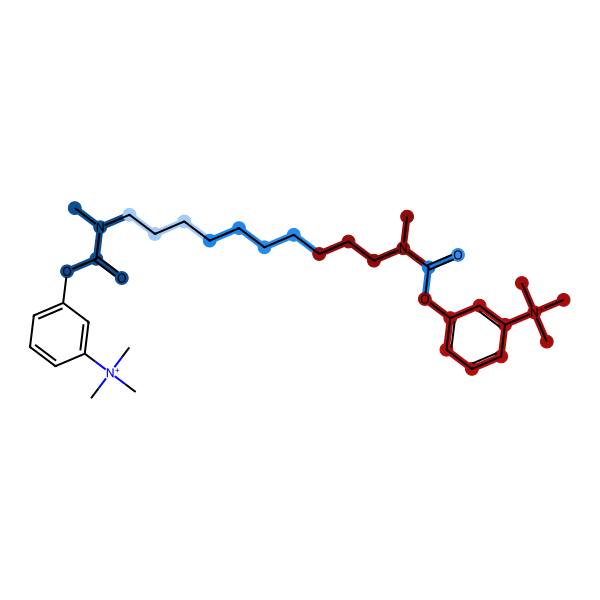

[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] non-ring atom 4 marked aromatic
[17:06:32] non-ring atom 2 marked aromatic
[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] non-ring atom 2 marked aromatic
[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] non-ring atom 0 marked aromatic
[17:06:32] 

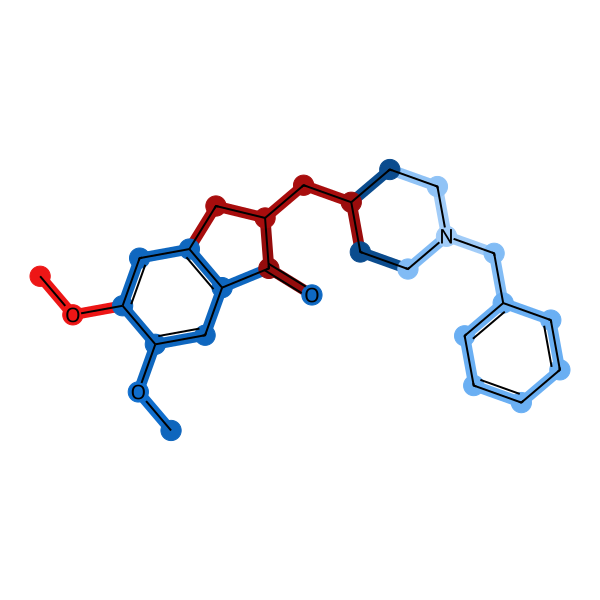

[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 8 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic


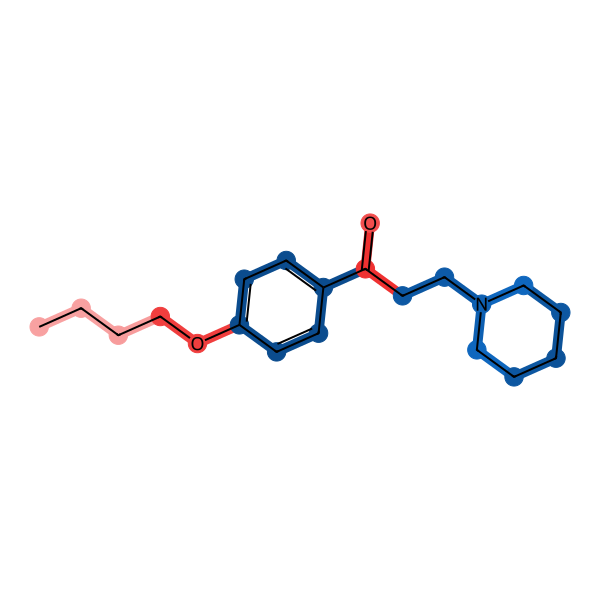

[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic


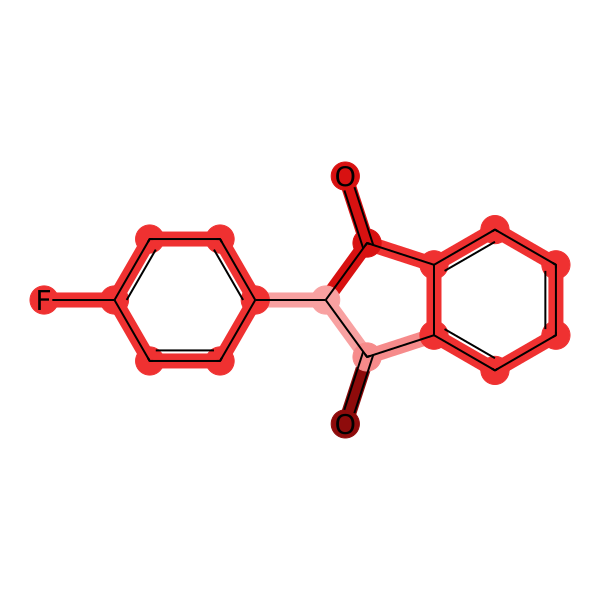

[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 1 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 7 marked aromatic
[17:06:33] non-ring atom 7 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 2 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 5 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 9 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 7 marked aromatic
[17:06:33] non-ring atom 5 marked aromatic
[17:06:33] non-ring atom 1 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] Can't kekulize mol.  Unkekulized atoms: 4 6 7 8 9


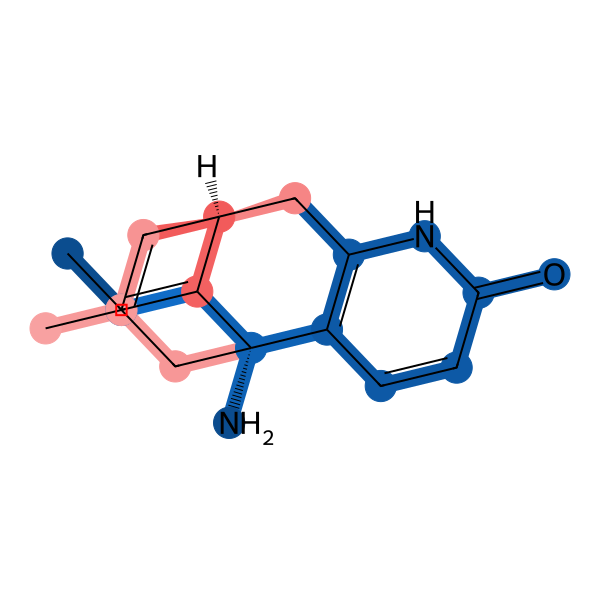

[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 2 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic


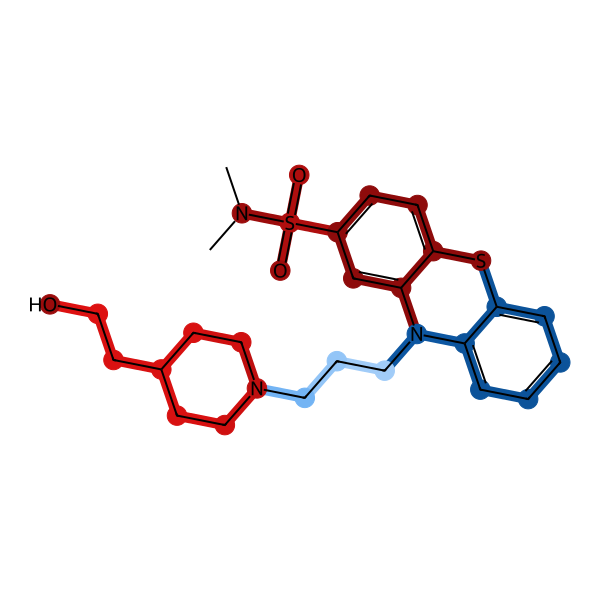

[17:06:33] non-ring atom 8 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic


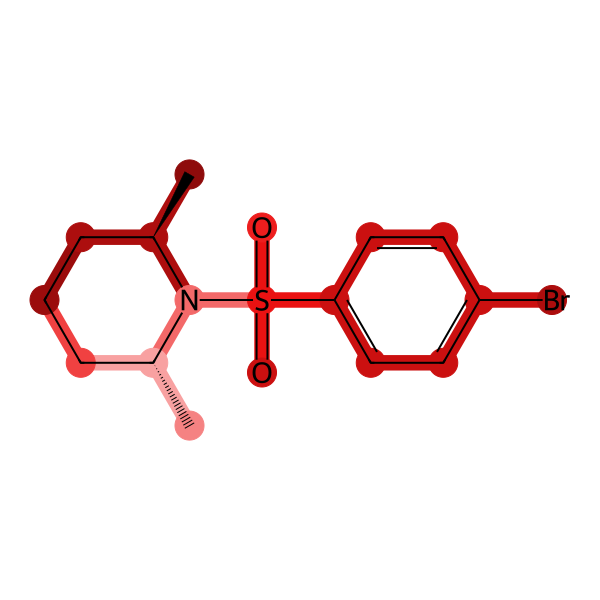

[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic


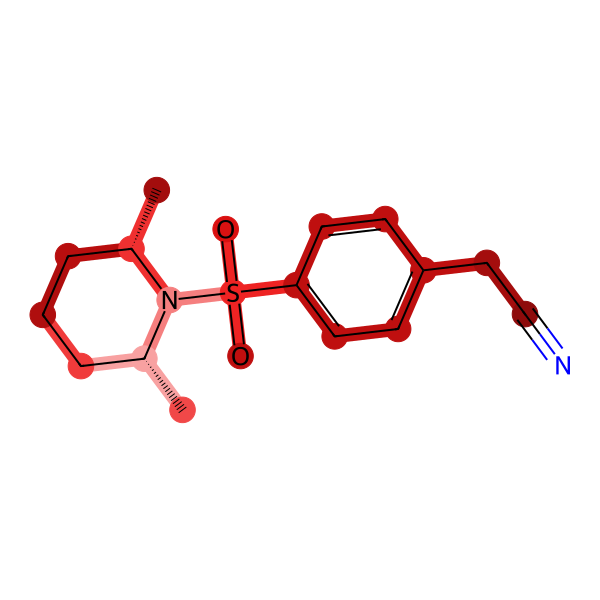

[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 2 marked aromatic


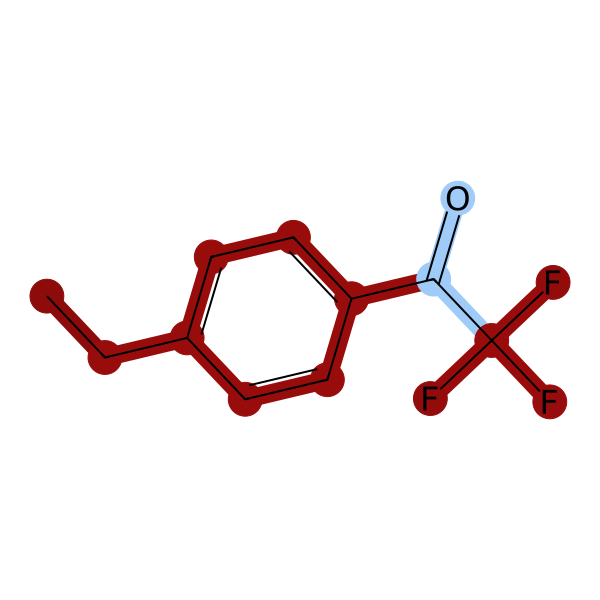

[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 6 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 6 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 8 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 2 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] 

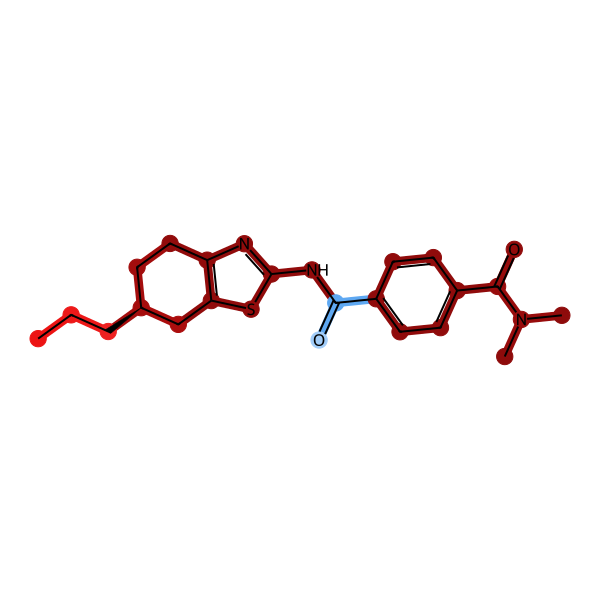

[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic


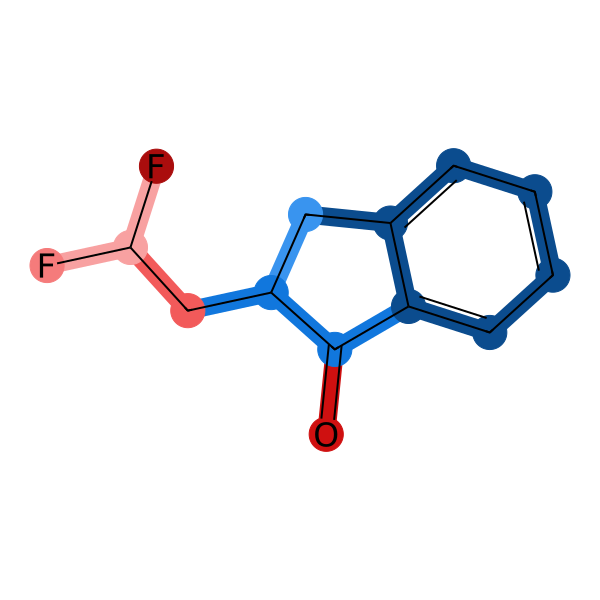

[17:06:33] non-ring atom 8 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 9 marked aromatic
[17:06:33] non-ring atom 1 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic


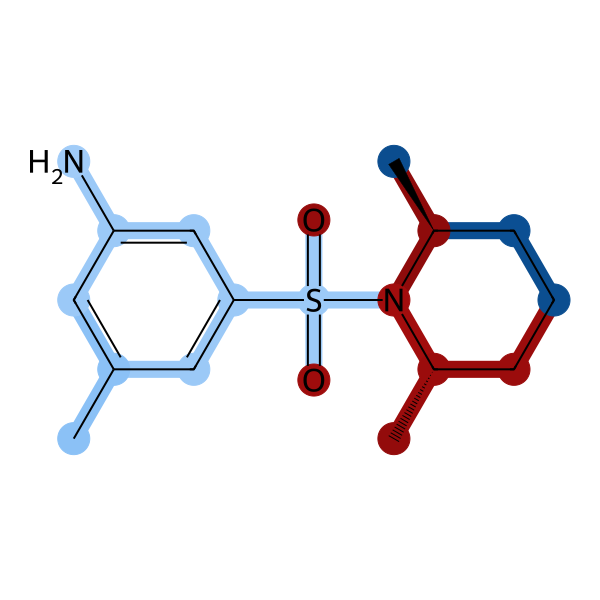

[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic


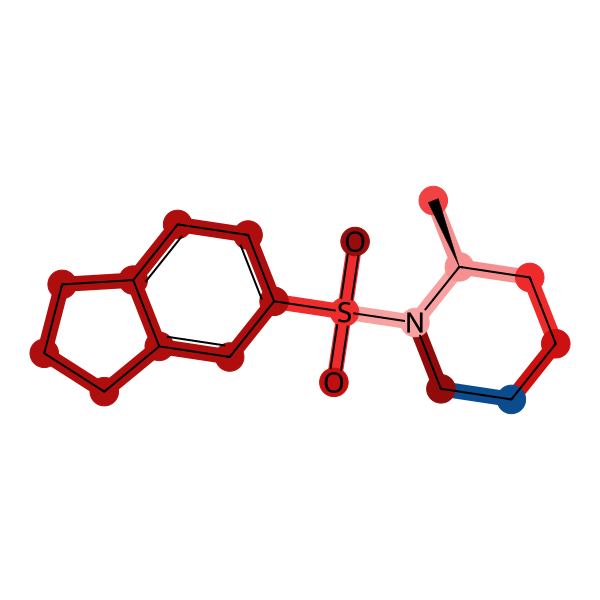

[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 2 marked aromatic
[17:06:33] non-ring atom 2 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic
[17:06:33] non-ring atom 0 marked aromatic


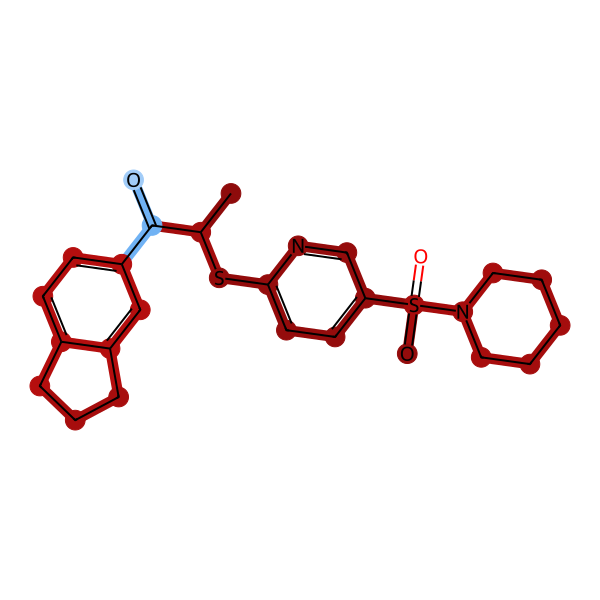

[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 6 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 1 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 8 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic


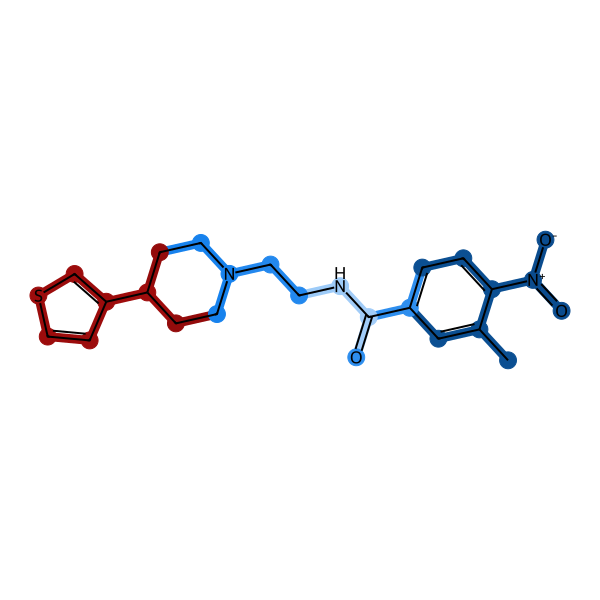

[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 2 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 8 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic


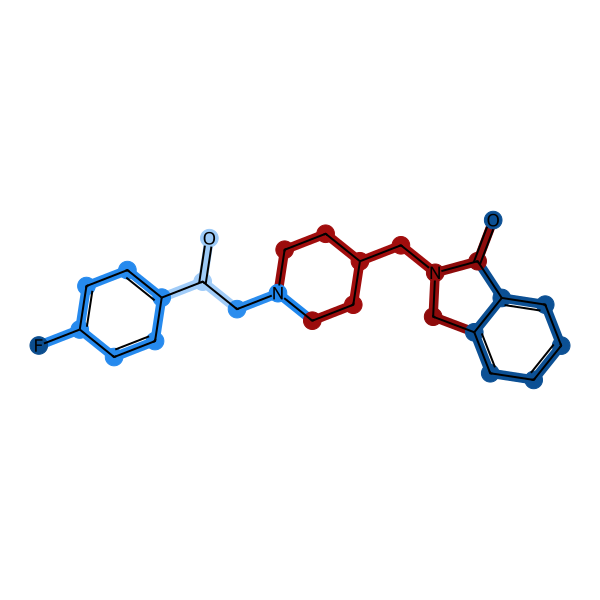

[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 10 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 2 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 2 marked aromatic
[17:06:34] non-ring atom 1 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 1 marked aromatic
[17:06:34] non-ring atom 2 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34]

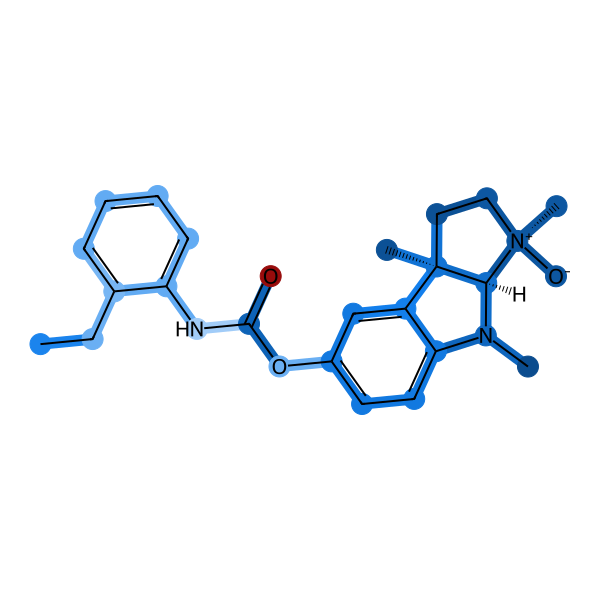

[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 6 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] 

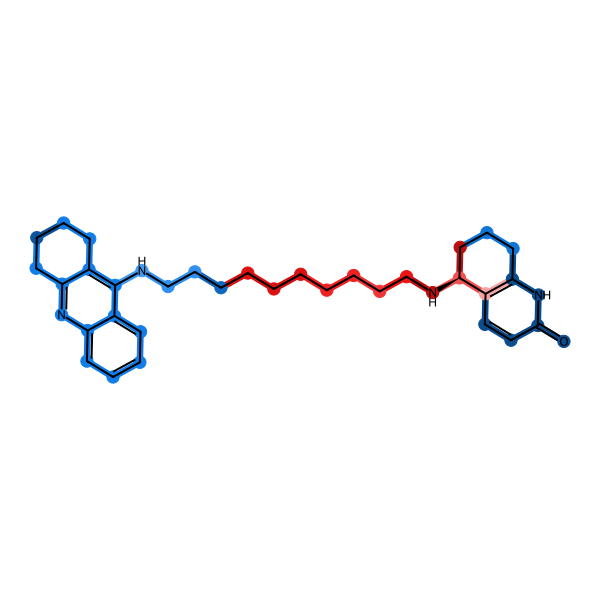

[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 1 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic


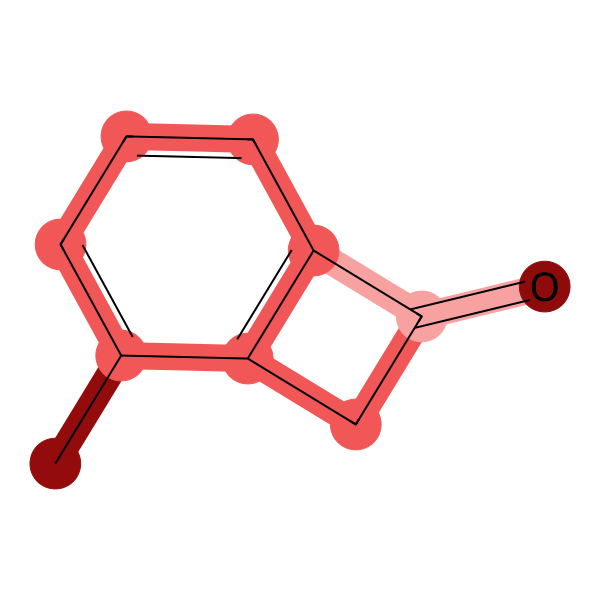

[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 5 marked aromatic
[17:06:34] non-ring atom 1 marked aromatic
[17:06:34] non-ring atom 5 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic


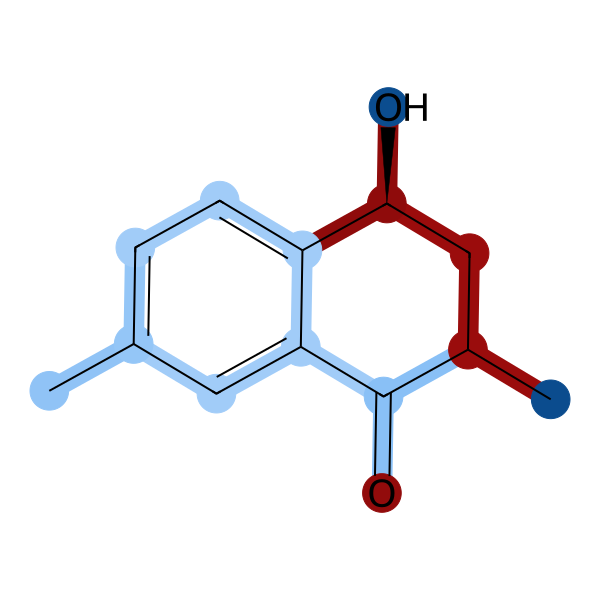

[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 5 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 1 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic


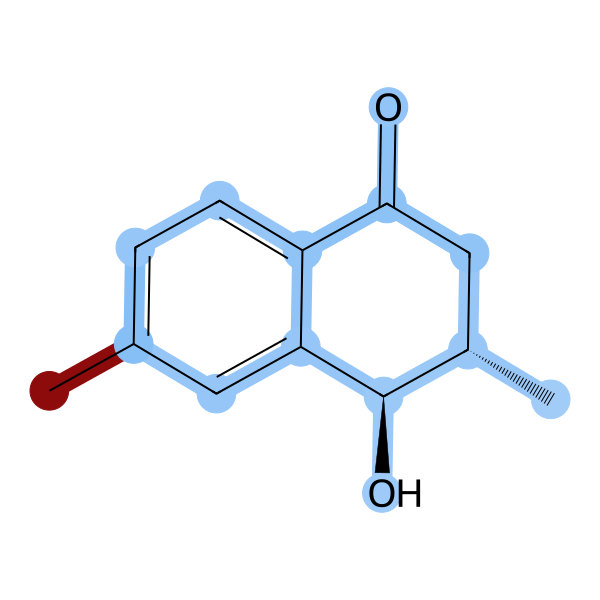

[17:06:34] Can't kekulize mol.  Unkekulized atoms: 2 3 5 6 7
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 2 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] Can't kekulize mol.  Unkekulized atoms: 2 3 5 6 7
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 8 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] Can't kekulize mol.  Unkekulized atoms: 2 5 6 8 9
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 4 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic
[17:06:34] non-ring atom 0 marked aromatic


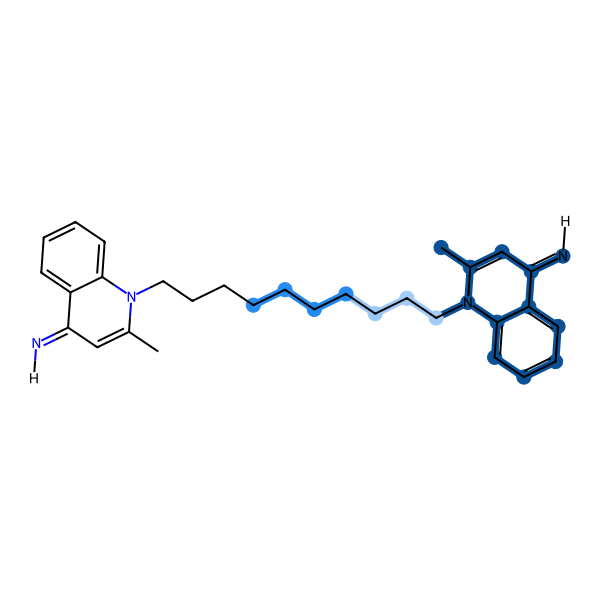

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
import io
import colorsys
from lime import lime_tabular
import numpy as np

# -------------------
# Helper functions
# -------------------

def weight_to_google_color(weight, min_weight, max_weight):
    if max_weight == min_weight:
        norm = 0.5
    else:
        norm = (abs(weight) - min_weight) / (max_weight - min_weight + 1e-6)
    lightness = 0.3 + 0.5 * norm
    saturation = 0.85
    hue = 210/360 if weight >= 0 else 0/360  # Blue for positive, red for negative
    r, g, b = colorsys.hls_to_rgb(hue, lightness, saturation)
    return (r, g, b)

def draw_molecule_with_weights(mol, atom_weights):
    drawer = rdMolDraw2D.MolDraw2DCairo(600, 600)
    options = drawer.drawOptions()
    options.atomHighlightsAreCircles = True

    if not atom_weights:
        return None

    weights = list(atom_weights.values())
    max_abs = max(abs(w) for w in weights)
    min_abs = min(abs(w) for w in weights)

    highlight_atoms = list(atom_weights.keys())
    highlight_colors = {
        idx: weight_to_google_color(atom_weights[idx], min_abs, max_abs)
        for idx in highlight_atoms
    }

    drawer.DrawMolecule(mol, highlightAtoms=highlight_atoms, highlightAtomColors=highlight_colors)
    drawer.FinishDrawing()
    png = drawer.GetDrawingText()
    img = Image.open(io.BytesIO(png))
    return img

def map_fragment_weights_to_atoms(parent_molecule, fragment_df):
    atom_weights = {}
    for idx, row in fragment_df.iterrows():
        fragment_smiles = row['Fragment_SMILES']
        fragment_weight = row['Fragment_Weight']
        fragment_molecule = Chem.MolFromSmiles(fragment_smiles)
        if fragment_molecule is None:
            continue
        if parent_molecule.HasSubstructMatch(fragment_molecule):
            match_atoms = parent_molecule.GetSubstructMatch(fragment_molecule)
            for atom_idx in match_atoms:
                atom_weights[atom_idx] = atom_weights.get(atom_idx, 0) + fragment_weight
    return atom_weights

# -------------------
# Prepare LIME Explainer
# -------------------

X_test = df_withFeatures_test.drop(columns=['Compound', 'Smiles', 'cleanedMol'])
X_train_features = X_train_scaled
feature_names = X_train_features.columns.tolist()

explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_features.values,
    feature_names=feature_names,
    categorical_features=[],  # fingerprints are continuous
    class_names=['0', '1'],
    discretize_continuous=True
)


def best_model_evaluator(x):
    return best_model.predict_proba(x)

# -------------------
# Fragment generation
# -------------------

# Function to generate fragment molecules from circular fingerprint bits
from rdkit.Chem import AllChem

def generate_circular_fingerprint_dict(mol, radius=4, nBits=1024):
    """
    Returns a dict mapping fingerprint bit index -> substructure Mol
    """
    bit_info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits, bitInfo=bit_info)
    fragments_dict = {}
    for bit_idx, info_list in bit_info.items():
        # take the first atom environment
        atom_idx, rad = info_list[0]
        env = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)
        submol = Chem.PathToSubmol(mol, env)
        fragments_dict[bit_idx] = submol
    return fragments_dict

# -------------------
# Generate fragment weights using LIME
# -------------------

all_data = []

for i, smi in enumerate(df_withFeatures_test['cleanedMol']):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue

    explanation = explainer.explain_instance(
        X_test.iloc[i].values,
        best_model_evaluator,
        num_features=500,
        top_labels=1
    )

    top_label = explanation.top_labels[0]
    feature_weights = dict(explanation.as_map()[top_label])

    fragments_activations = generate_circular_fingerprint_dict(mol)

    for bit_idx, submol in fragments_activations.items():
        if bit_idx in feature_weights:
            all_data.append({
                'ID': i,
                'Fragment_SMILES': Chem.MolToSmiles(submol),
                'Fragment_Weight': feature_weights[bit_idx]
            })

fragment_df = pd.DataFrame(all_data)

# -------------------
# Visualize molecules with atom highlights
# -------------------

for i, smi in enumerate(df_withFeatures_test['cleanedMol']):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue

    frag_df_for_mol = fragment_df[fragment_df['ID'] == i]
    atom_weights = map_fragment_weights_to_atoms(mol, frag_df_for_mol)
    img = draw_molecule_with_weights(mol, atom_weights)

    if img:
        display(img)
        # Optionally save:
        # img.save(f"highlighted_molecule_{i}.png")
